# 8. XGBoost Classifier

## Business Objective

Random Forest improved the predictive performance by combining multiple Decision Trees.

However, instead of building many independent trees, XGBoost builds trees sequentially, where each new tree attempts to correct the mistakes made by the previous trees.

XGBoost (Extreme Gradient Boosting) is one of the most powerful machine learning algorithms for structured data and is widely used in industry due to its speed, scalability, and predictive performance.

In this section, we build and evaluate an XGBoost classifier for customer churn prediction.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a classification model using common performance metrics.
    """

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print("=" * 50)
    print(f"Model : {model.__class__.__name__}")
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC Score: {auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model.__class__.__name__}")

    plt.show()

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob
    )

    plt.title(f"ROC Curve - {model.__class__.__name__}")
    plt.show()

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc
    }

In [3]:
X = pd.read_csv("../data/processed/X_scaled.csv")

y = pd.read_csv("../data/processed/y.csv")

y = y.squeeze()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Why XGBoost?

Unlike Random Forest, which builds many independent trees, XGBoost builds trees one after another.

Each new tree focuses on correcting the mistakes made by the previous trees.

Advantages:

- High predictive accuracy
- Handles nonlinear relationships
- Built-in regularization to reduce overfitting
- Fast and efficient
- Widely used in Kaggle competitions and industry

In [5]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [6]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Model : XGBClassifier
Accuracy : 0.7711
Precision: 0.5760
Recall   : 0.5267
F1 Score : 0.5503
AUC Score: 0.8114

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.58      0.53      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.70      1407
weighted avg       0.77      0.77      0.77      1407



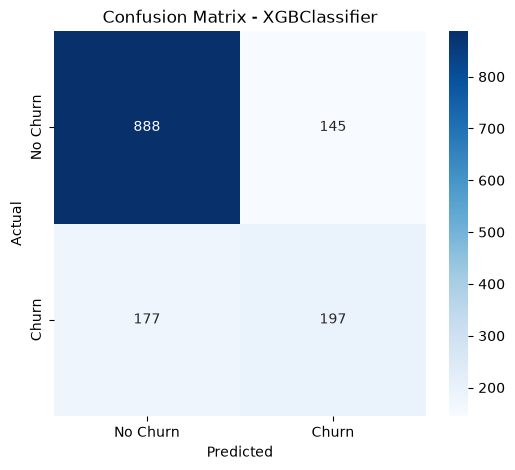

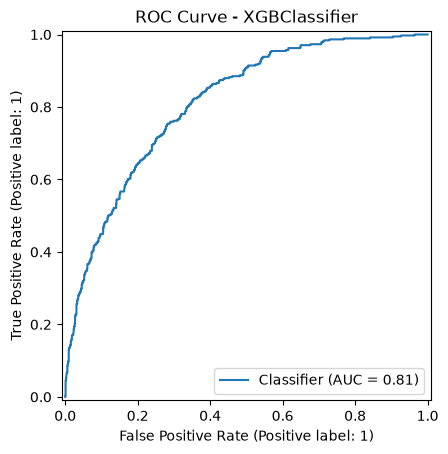

{'Model': 'XGBClassifier',
 'Accuracy': 0.7711442786069652,
 'Precision': 0.5760233918128655,
 'Recall': 0.5267379679144385,
 'F1 Score': 0.5502793296089385,
 'AUC': 0.8113899084231069}

In [7]:
results_xgb = evaluate_model(
    xgb_model,
    X_test,
    y_test
)

results_xgb

In [8]:
results_df = pd.DataFrame([results_xgb])

results_df.to_csv(
    "../results/xgboost_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


## Cross Validation

Cross-validation provides a more reliable estimate of model performance by evaluating the model across multiple train-test splits.

In [8]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(scores)

print("\nMean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Cross Validation Scores:
[0.77967306 0.79104478 0.76529161 0.79089616 0.79871977]

Mean Accuracy: 0.7851250756985243
Standard Deviation: 0.011629745846540465


In [9]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,InternetService_Fiber optic,0.446928
25,Contract_Two year,0.139514
11,InternetService_No,0.092819
24,Contract_One year,0.087552
1,tenure,0.023261
23,StreamingMovies_Yes,0.020556
9,MultipleLines_Yes,0.015032
28,PaymentMethod_Electronic check,0.014753
13,OnlineSecurity_Yes,0.013672
15,OnlineBackup_Yes,0.013632


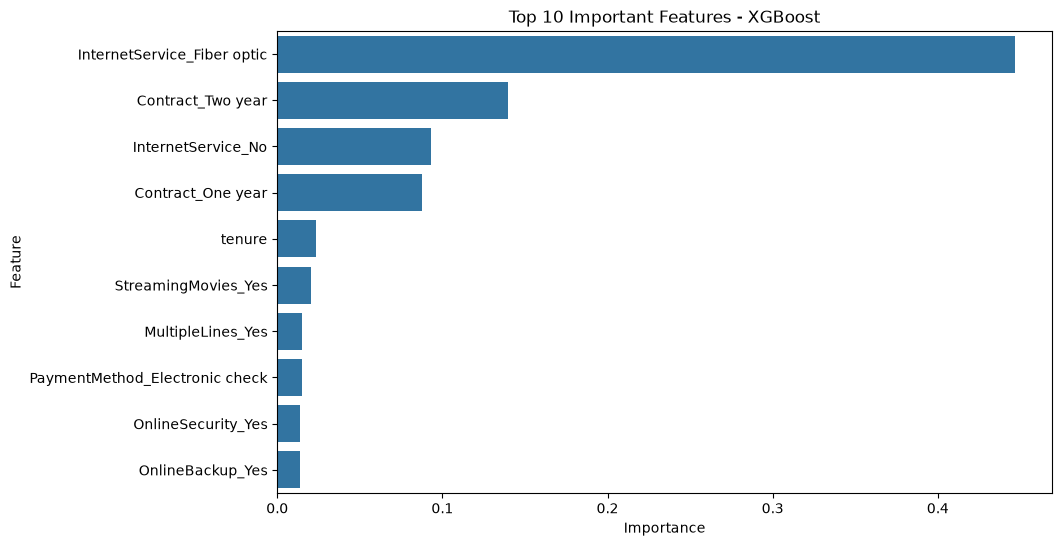

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - XGBoost")

plt.show()